# analisis 

Carga y procesa un dataset (HDF5) de simiulaciónes de campo magnetico 




In [21]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('imports OK')

imports OK


## 1. Configuración

Cambiá `H5_PATH` al dataset que quieras analizar.

In [22]:
# Localiza la raíz del repo (PMDKernel/) probando candidatos: distintos IDEs
# arrancan el notebook desde notebooks/, python/ o el repo raíz.
for candidate in (Path('.'), Path('..'), Path('../..')):
    cand = candidate.resolve()
    if (cand / 'data' / 'datasets').exists():
        REPO_ROOT = cand
        break
else:
    raise RuntimeError("No encontré 'data/datasets/' subiendo desde el cwd")

H5_PATH = REPO_ROOT / 'data' / 'datasets' / 'v3_xyz100_step50_n100k.h5'
assert H5_PATH.exists(), f'No existe: {H5_PATH}'

print(f'REPO_ROOT = {REPO_ROOT}')
print(f'H5_PATH   = {H5_PATH}')
print(f'tamaño    = {H5_PATH.stat().st_size / 1e6:.1f} MB')

REPO_ROOT = C:\Users\Poney\Desktop\Ipre\PMDKernel
H5_PATH   = C:\Users\Poney\Desktop\Ipre\PMDKernel\data\datasets\v3_xyz100_step50_n100k.h5
tamaño    = 377.2 MB


## 2. Carga del dataset

Layout **v2**: `geometria/grid/B (N, J, 3)` mT, `geometria/grid/R (J, 3)` mm, ejes `geometria/grid/meta/{x,y,z}`.

In [23]:
with h5py.File(H5_PATH, 'r') as f:
    B_mT   = f['geometria/grid/B'][:].astype(np.float32)        # (N, J, 3) en mT
    R_grid = f['geometria/grid/R'][:].astype(np.float32)        # (J, 3) mm
    grid_x = f['geometria/grid/meta/x'][:].astype(np.float32)
    grid_y = f['geometria/grid/meta/y'][:].astype(np.float32)
    grid_z = f['geometria/grid/meta/z'][:].astype(np.float32)
    attrs  = dict(f.attrs)

# Escalamos mT -> T antes de cualquier cálculo. El kernel CUDA `B0` devuelve
# Tesla y la pipeline guarda en mT
B = (B_mT * 1e-3).astype(np.float32)   # (N, J, 3) en T
del B_mT

N, J, _ = B.shape
Nx, Ny, Nz = len(grid_x), len(grid_y), len(grid_z)
assert J == Nx * Ny * Nz, f'J={J} != Nx*Ny*Nz={Nx*Ny*Nz}'

B_norm_mT = np.linalg.norm(B, axis=2) * 1e3       # (N, J) en mT — solo para reporte
kind = attrs.get('perturb_kind')
#kind = kind.decode() if isinstance(kind, bytes) else kind

print(f'unidades  : B almacenado en Tesla; valores reportados en mT')
print(f'N samples : {N}')
print(f'Grilla    : {Nx} x {Ny} x {Nz} = {J} puntos')
print(f'Rango x   : [{grid_x.min():>5.0f}, {grid_x.max():>5.0f}] mm   step = {grid_x[1]-grid_x[0]:.1f} mm')
print(f'Rango y   : [{grid_y.min():>5.0f}, {grid_y.max():>5.0f}] mm   step = {grid_y[1]-grid_y[0]:.1f} mm')
print(f'Rango z   : [{grid_z.min():>5.0f}, {grid_z.max():>5.0f}] mm   step = {grid_z[1]-grid_z[0]:.1f} mm')
print(f'Rango |B| : [{B_norm_mT.min():>7.3f}, {B_norm_mT.max():>7.3f}] mT')
print(f'Perturb   : kind={kind}, sigma_deg={attrs.get("perturb_sigma_deg")}')

unidades  : B almacenado en Tesla; valores reportados en mT
N samples : 100000
Grilla    : 5 x 5 x 5 = 125 puntos
Rango x   : [ -100,   100] mm   step = 50.0 mm
Rango y   : [ -100,   100] mm   step = 50.0 mm
Rango z   : [ -100,   100] mm   step = 50.0 mm
Rango |B| : [ 50.069,  60.000] mT
Perturb   : kind=b'both', sigma_deg=1.0


## 2.bis. Recorte de la ROI

Filtrado de `R_grid` según **z** + máscara radial cilíndrica 

In [24]:
Z_RANGE_MM    = (-100, 100)   # recorte axial, en mm
ROI_RADIUS_MM = 100            # radio del cilindro ROI en plano XY, en mm

r_xy     = np.linalg.norm(R_grid[:, :2], axis=1)        # (J,) radio al eje Z
mask_roi = (
    (R_grid[:, 2] >= Z_RANGE_MM[0]) &
    (R_grid[:, 2] <= Z_RANGE_MM[1]) &
    (r_xy <= ROI_RADIUS_MM)
)
J_roi      = int(mask_roi.sum())
B_roi      = B[:, mask_roi, :] # (N, J_roi, 3) en T
R_grid_roi = R_grid[mask_roi] # (J_roi, 3)
By_roi     = B_roi[..., 1] # (N, J_roi) en T

B_roi_norm_mT = np.linalg.norm(B_roi, axis=2) * 1e3     # (N, J_roi) en mT

print(f'recorte z   : [{Z_RANGE_MM[0]:>+5}, {Z_RANGE_MM[1]:>+5}] mm')
print(f'ROI radius  : {ROI_RADIUS_MM:.1f} mm   (cilindro alrededor del eje Z)')
print(f'puntos ROI  : {J_roi} de {J}   ({100*J_roi/J:.1f}% de la grilla original)')
print(f'|B| en ROI  : min = {B_roi_norm_mT.min():>7.3f} mT   max = {B_roi_norm_mT.max():>7.3f} mT')

recorte z   : [ -100,  +100] mm
ROI radius  : 100.0 mm   (cilindro alrededor del eje Z)
puntos ROI  : 65 de 125   (52.0% de la grilla original)
|B| en ROI  : min =  50.069 mT   max =  51.195 mT


### Visualización interactiva de la grilla y la ROI

Mapa de calor de **By** en cortes XY 

**Navegación**
- **`k_z`** slider — recorre los `Nz` cortes a lo largo de `z` va de `grid_z.min()` a `grid_z.max()`).
- **`sample`** slider — recorre las `N` configuraciones perturbadas.

**Guardado** (los archivos van al cwd del notebook, `python/notebooks/`)
- **`nombre`** — prefijo base del archivo.
- **`gif fps`** — frames por segundo del GIF.
- **PNG (frame)** — exporta el corte actual como `<nombre>_s<sample>_k<k_z>.png` a 150 dpi.
- **GIF (todo z)** — recorre los `Nz` cortes de la sample actual y arma `<nombre>_s<sample>.gif`.

El colorbar se calcula **por sample** (min/max de By sobre todos los cortes de la sample actual): es fijo y comparable entre slices, pero cada sample usa su propia escala. El mapa usa `pcolormesh` sobre la grilla regular (celdas discretas, sin los artefactos de interpolación de `tricontourf`); las celdas fuera de la ROI o vacías quedan en blanco. Debajo del plot, dos líneas reportan los rangos de `By` y `|B|` en el slice y avisan con `← clamp` cuando se tocan los 60 mT.

In [ ]:
import io
from pathlib import Path as _Path

import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image


z_layers  = np.unique(R_grid[:, 2])      # (Nz_layers,) valores únicos de z
Nz_layers = z_layers.size

# La escala del colormap se calcula POR SAMPLE dentro de _render_figure
# (min/max de By sobre TODOS los slices de ese sample). Así cada sample usa
# su propio rango: comparable entre slices, pero no entre samples distintos.


def _render_figure(sample_idx, k_z):
    """Crea y devuelve fig + arrays auxiliares. El caller cierra la fig."""
    z_slice  = float(z_layers[k_z])
    idx_z    = np.where(R_grid[:, 2] == z_slice)[0]              # (P,) índices del slice
    xs_all   = R_grid[idx_z, 0]
    ys_all   = R_grid[idx_z, 1]
    B_slice  = B[sample_idx, idx_z, :]                            # (P, 3) en T
    By_mT    = B_slice[:, 1] * 1e3                                # (P,) en mT
    Babs_mT  = np.linalg.norm(B_slice, axis=1) * 1e3              # (P,) en mT
    in_roi   = np.sqrt(xs_all**2 + ys_all**2) <= ROI_RADIUS_MM

    # Escala POR SAMPLE: min/max de By sobre todos los slices de este sample.
    By_sample_mT = B[sample_idx, :, 1] * 1e3
    vmin, vmax   = float(By_sample_mT.min()), float(By_sample_mT.max())

    # Reconstrucción de la grilla regular (x, y) del slice para pcolormesh:
    # celdas discretas con el valor real, sin la interpolación que mete
    # tricontourf (que generaba artefactos visuales).
    xu, yu = np.unique(xs_all), np.unique(ys_all)
    ix = np.searchsorted(xu, xs_all)
    iy = np.searchsorted(yu, ys_all)
    dx = float(xu[1] - xu[0]) if xu.size > 1 else 1.0
    dy = float(yu[1] - yu[0]) if yu.size > 1 else 1.0
    xe = np.r_[xu - dx / 2, xu[-1] + dx / 2]                      # bordes de celda en x
    ye = np.r_[yu - dy / 2, yu[-1] + dy / 2]                      # bordes de celda en y
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('white')                                         # celdas vacías / fuera de ROI

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
    panels = [
        (axes[0], np.ones_like(in_roi, dtype=bool), 'grilla completa'),
        (axes[1], in_roi, f'solo ROI (r_xy ≤ {ROI_RADIUS_MM} mm)'),
    ]
    for ax, sel, subtitle in panels:
        img = np.full((yu.size, xu.size), np.nan)
        img[iy[sel], ix[sel]] = By_mT[sel]
        pcm = ax.pcolormesh(xe, ye, np.ma.masked_invalid(img),
                            cmap=cmap, vmin=vmin, vmax=vmax, shading='flat')
        fig.colorbar(pcm, ax=ax, label='By [mT]')
        ax.add_patch(plt.Circle((0, 0), ROI_RADIUS_MM,
                                fill=False, ec='black', lw=1.5, ls='--'))
        ax.set_aspect('equal')
        ax.set_xlabel('x [mm]')
        ax.set_ylabel('y [mm]')
        ax.set_title(f'By — {subtitle}')
        ax.invert_xaxis()

    fig.suptitle(f'sample {sample_idx} — slice XY @ z = {z_slice:+.0f} mm  '
                 f'(k_z = {k_z}, {idx_z.size} puntos)')
    fig.tight_layout()
    return fig, By_mT, Babs_mT, in_roi, vmin, vmax


# --- Widgets ---
default_k = int(np.argmin(np.abs(z_layers)))

play_widget   = widgets.Play(value=default_k, min=0, max=Nz_layers-1, step=1,
                             interval=300, description='▶')
k_z_slider    = widgets.IntSlider(value=default_k, min=0, max=Nz_layers-1, description='k_z')
sample_slider = widgets.IntSlider(value=0, min=0, max=N-1, description='sample')
fps_slider    = widgets.IntSlider(value=5, min=1, max=20, description='gif fps')
fname_input   = widgets.Text(value='analisis_by', description='nombre')
save_png_btn  = widgets.Button(description='PNG (frame)',  icon='image',
                               button_style='info')
save_gif_btn  = widgets.Button(description='GIF (todo z)', icon='film',
                               button_style='warning')
status        = widgets.HTML(value='')

widgets.jslink((play_widget, 'value'), (k_z_slider, 'value'))

out_plot = widgets.Output()


def _redraw(*_):
    with out_plot:
        clear_output(wait=True)
        fig, By_mT, Babs_mT, in_roi, vmin, vmax = _render_figure(sample_slider.value, k_z_slider.value)
        plt.show()
        if in_roi.any():
            By_in   = By_mT[in_roi]
            Babs_in = Babs_mT[in_roi]
            print(f'slice·ROI :  By  ∈ [{By_in.min():>+7.3f}, {By_in.max():>+7.3f}] mT   '
                  f'|B| ∈ [{Babs_in.min():>7.3f}, {Babs_in.max():>7.3f}] mT')
        else:
            print('slice·ROI :  (sin puntos dentro de la ROI en este slice)')
        clamp = '   ← clamp (60 mT)' if Babs_mT.max() >= 60.0 - 1e-3 else ''
        print(f'slice full: |B| max = {Babs_mT.max():>7.3f} mT{clamp}')
        print(f'colorbar  :  By  ∈ [{vmin:>+7.3f}, {vmax:>+7.3f}] mT   (escala del sample {sample_slider.value}, fija entre slices)')


def _on_save_png(_btn):
    fig, *_ = _render_figure(sample_slider.value, k_z_slider.value)
    path = _Path(f'{fname_input.value}_s{sample_slider.value}_k{k_z_slider.value:02d}.png').resolve()
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    status.value = f'<b>PNG guardado:</b> <code>{path}</code>'


def _on_save_gif(_btn):
    sample = sample_slider.value
    fps    = fps_slider.value
    path   = _Path(f'{fname_input.value}_s{sample}.gif').resolve()
    save_gif_btn.disabled = True
    try:
        frames = []
        for k in range(Nz_layers):
            status.value = f'rendereando frame {k+1}/{Nz_layers}…'
            fig, *_ = _render_figure(sample, k)
            buf = io.BytesIO()
            fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
            plt.close(fig)
            buf.seek(0)
            frames.append(Image.open(buf).convert('RGB'))
        frames[0].save(path, save_all=True, append_images=frames[1:],
                       duration=int(1000 / fps), loop=0, optimize=True)
        status.value = f'<b>GIF guardado:</b> <code>{path}</code> ({Nz_layers} frames @ {fps} fps)'
    finally:
        save_gif_btn.disabled = False


k_z_slider.observe(_redraw,    names='value')
sample_slider.observe(_redraw, names='value')
save_png_btn.on_click(_on_save_png)
save_gif_btn.on_click(_on_save_gif)

display(widgets.VBox([
    widgets.HBox([play_widget, k_z_slider, sample_slider]),
    widgets.HBox([fname_input, fps_slider, save_png_btn, save_gif_btn]),
    status,
    out_plot,
]))
_redraw()

## 3. Inhomogeneidad de |By| — una configuración

Tomamos un sample (`SAMPLE_IDX`), pasamos a magnitud `|By|` y reducimos sobre los `J_roi` puntos de la ROI. Reportamos `(max - min) / mean` (adimensional) y su valor en ppm. Trabajar con `|By|` evita el signo artificial: B0 apunta sobre -Y → todos los `By` son negativos, pero la inhomogeneidad mide dispersión relativa de la intensidad y no debe depender de la convención de signo.

In [26]:
SAMPLE_IDX = 1249

# Trabajamos con la magnitud |By|: B0 en el OSI² apunta sobre -Y, así que By
# es negativo en toda la ROI. La inhomogeneidad mide dispersión relativa de la
# intensidad del campo, así que el signo no debe entrar en la cuenta.
By_abs = np.abs(By_roi[SAMPLE_IDX])   # (J_roi,) en T — storage en T (display en mT abajo)

By_min  = float(By_abs.min())
By_max  = float(By_abs.max())
By_mean = float(By_abs.mean())

inhomo     = (By_max - By_min) / By_mean  
inhomo_ppm = inhomo * 1e6

print(f'Sample idx     : {SAMPLE_IDX}   (de {N})')
print(f'puntos en ROI  : J_roi = {J_roi}   (radio xy = {ROI_RADIUS_MM:.1f} mm)')
print(f'|By|_min       : {By_min*1e3:>9.4f} mT')
print(f'|By|_max       : {By_max*1e3:>9.4f} mT')
print(f'|By|_mean      : {By_mean*1e3:>9.4f} mT')
print(f'(max-min)/mean : {inhomo:.6e}')
print(f'inhomogeneidad : {inhomo_ppm:.3e} ppm')

Sample idx     : 1249   (de 100000)
puntos en ROI  : J_roi = 65   (radio xy = 100.0 mm)
|By|_min       :   50.2806 mT
|By|_max       :   50.9127 mT
|By|_mean      :   50.7346 mT
(max-min)/mean : 1.245880e-02
inhomogeneidad : 1.246e+04 ppm


## 4. Inhomogeneidad sobre las N configuraciones

Aplicamos el mismo cálculo a todas las samples (vectorizado) y reportamos mean / std / min / max / percentiles del valor en ppm.

In [28]:
By_abs       = np.abs(By_roi)            # (N, J_roi) — magnitudes
By_min_all   = By_abs.min(axis=1)         # (N,)
By_max_all   = By_abs.max(axis=1)
By_mean_all  = By_abs.mean(axis=1)

inhomo_all     = (By_max_all - By_min_all) / By_mean_all
inhomo_ppm_all = inhomo_all * 1e6

print(f'Inhomogeneidad de |By| en ppm — ROI cilíndrica r_xy={ROI_RADIUS_MM:.0f} mm — {N} samples:')
print(f'  mean   : {inhomo_ppm_all.mean():.4e} ppm')
print(f'  std    : {inhomo_ppm_all.std():.4e} ppm')
print(f'  min    : {inhomo_ppm_all.min():.4e} ppm')
print(f'  p05    : {np.percentile(inhomo_ppm_all,  5):.4e} ppm')
print(f'  median : {np.median(inhomo_ppm_all):.4e} ppm')
print(f'  p95    : {np.percentile(inhomo_ppm_all, 95):.4e} ppm')
print(f'  max    : {inhomo_ppm_all.max():.4e} ppm')

Inhomogeneidad de |By| en ppm — ROI cilíndrica r_xy=100 mm — 100000 samples:
  mean   : 1.3909e+04 ppm
  std    : 1.0287e+03 ppm
  min    : 1.0350e+04 ppm
  p05    : 1.2374e+04 ppm
  median : 1.3824e+04 ppm
  p95    : 1.5738e+04 ppm
  max    : 2.0119e+04 ppm


## 5. Distribución de la inhomogeneidad sobre samples

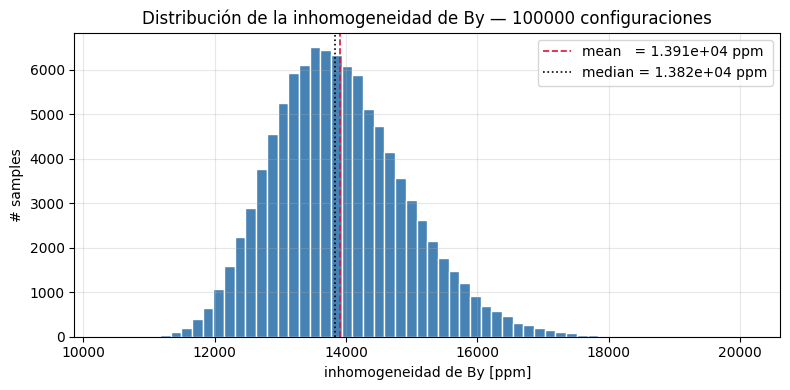

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(inhomo_ppm_all, bins=60, color='steelblue', edgecolor='white')
plt.axvline(inhomo_ppm_all.mean(),    color='crimson', ls='--', lw=1.2,
            label=f'mean   = {inhomo_ppm_all.mean():.3e} ppm')
plt.axvline(np.median(inhomo_ppm_all), color='black',  ls=':',  lw=1.2,
            label=f'median = {np.median(inhomo_ppm_all):.3e} ppm')
plt.xlabel('inhomogeneidad de By [ppm]')
plt.ylabel('# samples')
plt.title(f'Distribución de la inhomogeneidad de By — {N} configuraciones')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Modelos — registro y carga

Editá `MODEL_REGISTRY` en la siguiente celda para agregar o quitar modelos. Cada entrada necesita: `name` (etiqueta), `version` (`"v4"` o `"v5"`), `ckpt`, `aux` y `h5_test`.

Las tres celdas de abajo (1) definen el registro, (2) exponen las funciones de carga/predicción y (3) cargan todos los modelos válidos en el dict `MODELS` que usan las secciones §7 y §8.

In [29]:
import sys, torch, numpy as np, h5py
from pathlib import Path

sys.path.insert(0, str(REPO_ROOT / "python"))

# ─── Editá esta lista para agregar / quitar modelos ──────────────────────────
#  Campos por entrada:
#    name     : etiqueta legible (se usa en dropdowns y tablas)
#    version  : "v4" | "v5"  (determina qué clase Lightning cargar)
#    ckpt     : Path al .ckpt de Lightning  (OBLIGATORIO)
#    aux      : Path al _aux.pt de train_v*.py (OPCIONAL: solo aporta la columna
#               de métricas; los scalers van horneados en el .ckpt)
#    h5_test  : Path al HDF5 holdout independiente (nunca visto en training)
MODEL_REGISTRY = [
    dict(
        name    = "v4 · step10 · n5000",
        version = "v4",
        ckpt    = REPO_ROOT / "python/Models/v4_deepsets/logs"
                  / "v4_deepsets_v1_xyz100_step10_n5000"
                  / "v4_deepsets_v1_xyz100_step10_n5000.ckpt",
        aux     = REPO_ROOT / "python/Models/v4_deepsets/logs"
                  / "v4_deepsets_v1_xyz100_step10_n5000"
                  / "v4_deepsets_v1_xyz100_step10_n5000_aux.pt",
        h5_test = REPO_ROOT / "data/datasets/test_og.h5",
    ),
    dict(
        name    = "v5-PINN · step50 · n5000",
        version = "v5",
        ckpt    = REPO_ROOT / "python/Models/v5_deepsets_pinn/logs"
                  / "v5_pinn_v2_n5000_colab"
                  / "v5_pinn_v2_n5000_colab.ckpt",
        aux     = REPO_ROOT / "python/Models/v5_deepsets_pinn/logs"
                  / "v5_pinn_v2_n5000_colab"
                  / "v5_pinn_v2_n5000_colab_aux.pt",
        h5_test = REPO_ROOT / "data/datasets/test_og_v2.h5",
    ),
    dict(
        name    = "v5-PINN · step50 · n100k",
        version = "v5",
        ckpt    = REPO_ROOT / "python/Models/v5_deepsets_pinn/logs"
                  / "v5_pinn_v2_n100k_colab"
                  / "v5_pinn_v2_n100k_colab.ckpt",
        aux     = REPO_ROOT / "python/Models/v5_deepsets_pinn/logs"
                  / "v5_pinn_v2_n100k_colab"
                  / "v5_pinn_v2_n100k_colab_aux.pt",   # no existe aún → carga sin métricas
        h5_test = REPO_ROOT / "data/datasets/test_og_v2.h5",
    ),
]
print(f"{len(MODEL_REGISTRY)} modelo(s) en el registro.")

3 modelo(s) en el registro.


In [30]:
def _load_model_entry(entry, device):
    """Carga el LightningModule correcto según entry['version']."""
    v = entry["version"]
    if v == "v4":
        from Models.v4_deepsets.model import LitDeepSet
        return LitDeepSet.load_from_checkpoint(
            str(entry["ckpt"]), map_location=device, weights_only=False
        ).eval().to(device)
    if v == "v5":
        from Models.v5_deepsets_pinn.model import LitDeepSetPINN
        return LitDeepSetPINN.load_from_checkpoint(
            str(entry["ckpt"]), map_location=device, weights_only=False
        ).eval().to(device)
    raise ValueError(f"version desconocida: {v!r}")


def predict_by_mT(model, version, sensors_t, query_t, chunk=8192):
    """By [mT] para J puntos → np.ndarray (J,). Compatible con v4 y v5.

    v4: predict_mT devuelve (K, 1) → squeeze.
    v5: predict_mT devuelve (K, 3) = (Bx, By, Bz) → índice 1.
    """
    J   = query_t.shape[0]
    out = np.empty(J, dtype=np.float32)
    with torch.no_grad():
        for s in range(0, J, chunk):
            e    = s + chunk
            pred = model.predict_mT(sensors_t[s:e], query_t[s:e])
            out[s:e] = (pred[:, 1] if version == "v5"
                        else pred.squeeze(-1)).cpu().numpy()
    return out

In [31]:
import pathlib, platform
if platform.system() == 'Windows':
    pathlib.PosixPath = pathlib.WindowsPath

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device : {device}\n")

MODELS = {}   # name → {"model", "aux", "entry"}

col_w  = max(len(e["name"]) for e in MODEL_REGISTRY) + 2
sep    = "─" * (col_w + 50)
header = f"  {'nombre':<{col_w}}  {'RMSE test (train split)':>23}  {'R²':>7}  estado"
print(header); print(sep)

for entry in MODEL_REGISTRY:
    # Solo el .ckpt es obligatorio: los scalers van horneados como buffers del
    # checkpoint (b_mean/b_std/feat_*), así que predict_mT — y por ende §8/§9 —
    # no necesita el _aux.pt. El aux es opcional y solo aporta las métricas de
    # training que se imprimen abajo.
    if not entry["ckpt"].exists():
        print(f"  {entry['name']:<{col_w}}  {'':>23}  {'':>7}  ✗ falta: ckpt")
        continue

    aux   = (torch.load(str(entry["aux"]), map_location="cpu", weights_only=False)
             if entry["aux"].exists() else None)
    model = _load_model_entry(entry, device)
    MODELS[entry["name"]] = dict(model=model, aux=aux, entry=entry)

    if aux is not None and "metrics" in aux:
        m = aux["metrics"]["test"]
        print(f"  {entry['name']:<{col_w}}  {m['rmse_mt']:>20.4f} mT  {m['r2']:>+7.4f}  ✓")
    else:
        print(f"  {entry['name']:<{col_w}}  {'— (sin aux)':>23}  {'—':>7}  ✓")

print(sep)
print(f"\n{len(MODELS)}/{len(MODEL_REGISTRY)} modelo(s) listos en MODELS.")

device : cuda

  nombre                      RMSE test (train split)       R²  estado
────────────────────────────────────────────────────────────────────────────
  v4 · step10 · n5000                       0.2178 mT  +0.9046  ✓
  v5-PINN · step50 · n5000                  0.3406 mT  +0.9801  ✓
  v5-PINN · step50 · n100k                — (sin aux)        —  ✓
────────────────────────────────────────────────────────────────────────────

3/3 modelo(s) listos en MODELS.


c:\Users\Poney\Desktop\Ipre\.venv\Lib\site-packages\pytorch_lightning\utilities\migration\utils.py:56: The loaded checkpoint was produced with Lightning v2.6.4, which is newer than your current Lightning version: v2.6.1


## 7. Comparativa sobre el holdout independiente

Evalúa cada modelo sobre su `h5_test` (muestras **nunca vistas** durante el entrenamiento). Como v4 y v5 usan grillas distintas (step=10 → J=9 261, step=50 → J=125), las métricas en mT no son directamente comparables en valor absoluto; sirven para verificar que cada modelo generaliza bien dentro de su dominio.

Ajustá `N_EVAL` para un subset rápido o `None` para el holdout completo.

In [33]:
print(MODELS)

{'v4 · step10 · n5000': {'model': LitDeepSet(
  (net): DeepSetModel(
    (phi): Sequential(
      (0): Linear(in_features=5, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=128, bias=True)
    )
    (rho): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (train_mse): MeanSquaredError()
  (val_mse): MeanSquaredError()
), 'aux': {'b_mean': -50.8284391953385, 'b_std': 0.705021796411317, 'feat_mean': array([ 7.8125447e-02, -1.3183610e+00, -2.0312500e+00,  2.8459232e+02,
        4.8997679e+00], dtype=float32), 'feat_std': array([195.93208 , 195.59656 , 107.69075 ,  59.53416 ,   9.162782],
      dtype=float32), 'sensor_xyz': array([[  -0.      ,  265.      , -128.      ],
 

In [34]:
import pandas as pd
from IPython.display import display

# Cuántas muestras del holdout evaluar (None = todas; 100 es rápido para smoke test)
N_EVAL = 100

rows = []
for name, m_entry in MODELS.items():
    entry   = m_entry["entry"]
    model   = m_entry["model"]
    version = entry["version"]
    h5_path = entry["h5_test"]

    if not h5_path.exists():
        rows.append({"modelo": name, "J": "–", "N_eval": "–",
                     "RMSE_mT": "–", "R²": "–", "nota": "h5_test no existe"})
        continue

    with h5py.File(h5_path, "r") as f:
        N_tot   = f["geometria/grid/B"].shape[0]
        R_grid_ = f["geometria/grid/R"][:].astype(np.float32)          # (J, 3)
        n_eval  = N_tot if N_EVAL is None else min(N_EVAL, N_tot)
        B_sens_ = f["geometria/sens/B"][:n_eval, :, 1].astype(np.float32)  # (n_eval, I)
        B_grid_ = f["geometria/grid/B"][:n_eval, :, 1].astype(np.float32)  # (n_eval, J)

    J       = R_grid_.shape[0]
    I       = B_sens_.shape[1]
    query_t = torch.from_numpy(R_grid_).to(device)

    errs = []
    for s_idx in range(n_eval):
        sens_rep = np.broadcast_to(B_sens_[s_idx], (J, I)).copy()
        sens_t   = torch.from_numpy(sens_rep).to(device)
        by_pred  = predict_by_mT(model, version, sens_t, query_t)
        errs.append(by_pred - B_grid_[s_idx])

    err_all  = np.stack(errs)        # (n_eval, J)
    true_all = B_grid_
    rmse = float(np.sqrt(np.mean(err_all**2)))
    r2   = float(1 - (err_all**2).sum()
                 / ((true_all - true_all.mean())**2).sum())
    rows.append({"modelo": name, "J": J, "N_eval": n_eval,
                 "RMSE_mT": f"{rmse:.4f}", "R²": f"{r2:+.4f}"})
    print(f"  {name}: RMSE={rmse:.4f} mT   R²={r2:+.4f}   (J={J}, N_eval={n_eval})")

print()
display(pd.DataFrame(rows))

  v4 · step10 · n5000: RMSE=0.2196 mT   R²=+0.9028   (J=9261, N_eval=100)
  v5-PINN · step50 · n5000: RMSE=0.3389 mT   R²=+0.9737   (J=125, N_eval=100)
  v5-PINN · step50 · n100k: RMSE=0.3320 mT   R²=+0.9748   (J=125, N_eval=100)



,modelo,J,N_eval,RMSE_mT,R²
0,v4 · step10 · n5000,9261,100,0.2196,+0.9028
1,v5-PINN · step50 · n5000,125,100,0.3389,+0.9737
2,v5-PINN · step50 · n100k,125,100,0.3320,+0.9748


## 8. Inferencia interactiva

### 8.1 Métricas por muestra

Elegí modelo y posición de muestra en las variables de arriba del bloque. El modelo se toma de `MODELS` (cargado en §6); por eso §6 debe haber corrido antes.

### 8.2 Slice X–Y y perfil axial

Dropdown de modelo + sliders de corte Z y sample. Cambiar el modelo recarga la grilla y limpia el caché de inferencia automáticamente.

In [35]:
# ─── Selecciona modelo y muestra ─────────────────────────────────────────────
MODEL_NAME = list(MODELS.keys())[0]   # cambiá al nombre que querés analizar
SAMPLE_POS = 0                         # posición 0..N_holdout-1 en el archivo de test especializado

m_entry  = MODELS[MODEL_NAME]
entry    = m_entry["entry"]
model    = m_entry["model"]
aux      = m_entry["aux"]
version  = entry["version"]
h5_test  = entry["h5_test"]

with h5py.File(h5_test, "r") as f:
    N_holdout = f["geometria/grid/B"].shape[0]
    assert 0 <= SAMPLE_POS < N_holdout, (
        f"SAMPLE_POS={SAMPLE_POS} fuera de rango [0, {N_holdout}) en {h5_test.name}"
    )
    sample_id  = SAMPLE_POS  # holdout especializado: todas las muestras son test
    sensors_by = f["geometria/sens/B"][sample_id][..., 1].astype(np.float32)  # (I,)
    R_grid_    = f["geometria/grid/R"][:].astype(np.float32)                   # (J, 3)
    by_true    = f["geometria/grid/B"][sample_id][..., 1].astype(np.float32)  # (J,) mT
    gx_ = f["geometria/grid/meta/x"][:].astype(np.float32)
    gy_ = f["geometria/grid/meta/y"][:].astype(np.float32)
    gz_ = f["geometria/grid/meta/z"][:].astype(np.float32)

J, I   = R_grid_.shape[0], sensors_by.shape[0]
sens_t = torch.from_numpy(np.broadcast_to(sensors_by, (J, I)).copy()).to(device)
qry_t  = torch.from_numpy(R_grid_).to(device)
by_pred = predict_by_mT(model, version, sens_t, qry_t)

err  = by_pred - by_true
rmse = float(np.sqrt(np.mean(err**2)))
mae  = float(np.abs(err).mean())
maxe = float(np.abs(err).max())
r2   = float(1 - (err**2).sum() / ((by_true - by_true.mean())**2).sum())

print(f"Modelo    : {MODEL_NAME}  (versión {version})")
print(f"Holdout   : {h5_test.name}  ({N_holdout} muestras)")
print(f"Sample    : pos {SAMPLE_POS} (id local #{sample_id} en el holdout)")
print(f"Grid      : {len(gx_)}×{len(gy_)}×{len(gz_)} = {J} puntos   I={I} sensores")
print(f"By true   : [{by_true.min():+.3f}, {by_true.max():+.3f}] mT")
print(f"RMSE      : {rmse:.4e} mT")
print(f"MAE       : {mae:.4e} mT")
print(f"max|Δ|    : {maxe:.4e} mT   ({100*maxe/np.abs(by_true).max():.2f}% del |By| max)")
print(f"R²        : {r2:+.4f}")

Modelo    : v4 · step10 · n5000  (versión v4)
Holdout   : test_og.h5  (500 muestras)
Sample    : pos 0 (id local #0 en el holdout)
Grid      : 21×21×21 = 9261 puntos   I=180 sensores
By true   : [-59.220, -41.614] mT
RMSE      : 1.9138e-01 mT
MAE       : 1.4313e-01 mT
max|Δ|    : 1.8303e+00 mT   (3.09% del |By| max)
R²        : +0.9242


*Selección de muestra e inferencia integradas en la celda §8.1 de arriba.*

*Métricas por muestra disponibles en la celda §8.1.*

### 8.2 Slice X–Y interactivo — recorre modelos, samples y cortes en Z

Tres paneles: kernel (truth), predicción, error. El **dropdown de modelo** sincroniza el holdout y la grilla automáticamente — cambiar modelo limpia el caché de inferencia. Los botones de guardado exportan el frame o GIF actual.

**Navegación**
- **Dropdown modelo** — cambia el modelo activo (limpia caché y ajusta sliders).
- **▶ Play / Pause** — anima sobre todos los `k_z`.
- **`k_z`** — corte axial.
- **`sample`** — posición en el split test del modelo activo.

**Guardado** (archivos van al cwd del notebook)
- **`nombre`** / **`gif fps`** — prefijo y fps del GIF.
- **PNG (frame)** — exporta el corte actual a 150 dpi.
- **GIF (todo z)** — anima los `Nz` cortes de la sample actual.

In [36]:
import io
from pathlib import Path as _Path

import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

if not MODELS:
    print("No hay modelos en MODELS. Cargá al menos uno en §6.")
else:
    # ─── Estado compartido (leído también por la celda de perfil §8.3) ───────
    _state = {
        "name": None, "model": None, "version": None,
        "h5_test": None, "test_indices": None,
        "R_grid": None, "query_t": None,
        "gx": None, "gy": None, "gz": None,
        "Nx": None, "Ny": None, "Nz": None,
        "pred_cache": {},
    }

    def _load_state(name):
        """Carga metadata del holdout al _state si el modelo cambió.

        h5_test apunta a un archivo de test ESPECIALIZADO (todas las muestras
        son holdout). Por eso `test_indices` = np.arange(N_holdout); no usamos
        aux["splits"]["test"] (esos índices son globales del dataset de
        entrenamiento y no aplican a este archivo).
        """
        if name == _state["name"]:
            return
        m = MODELS[name]
        with h5py.File(m["entry"]["h5_test"], "r") as f:
            N_holdout = f["geometria/grid/B"].shape[0]
            R  = f["geometria/grid/R"][:].astype(np.float32)
            gx = f["geometria/grid/meta/x"][:].astype(np.float32)
            gy = f["geometria/grid/meta/y"][:].astype(np.float32)
            gz = f["geometria/grid/meta/z"][:].astype(np.float32)
        _state.update(
            name=name, model=m["model"], version=m["entry"]["version"],
            h5_test=m["entry"]["h5_test"],
            test_indices=np.arange(N_holdout, dtype=np.int64),
            R_grid=R, query_t=torch.from_numpy(R).to(device),
            gx=gx, gy=gy, gz=gz,
            Nx=len(gx), Ny=len(gy), Nz=len(gz),
        )
        _state["pred_cache"].clear()

    def _infer_sample(test_pos):
        """Predice (By_true, By_pred) en mT, shape (Nx, Ny, Nz). Cachea por idx."""
        idx = int(_state["test_indices"][test_pos])
        if idx in _state["pred_cache"]:
            return _state["pred_cache"][idx]
        J = _state["R_grid"].shape[0]
        with h5py.File(_state["h5_test"], "r") as f:
            sens = f["geometria/sens/B"][idx][..., 1].astype(np.float32)
            bt   = f["geometria/grid/B"][idx][..., 1].astype(np.float32)
        I  = sens.shape[0]
        Nx, Ny, Nz = _state["Nx"], _state["Ny"], _state["Nz"]
        st = torch.from_numpy(np.broadcast_to(sens, (J, I)).copy()).to(device)
        bp = predict_by_mT(_state["model"], _state["version"], st, _state["query_t"])
        r  = (bt.reshape(Nx, Ny, Nz), bp.reshape(Nx, Ny, Nz))
        _state["pred_cache"][idx] = r
        return r

    def _render_slice(test_pos, k_z):
        Bt, Bp = _infer_sample(test_pos)
        Ev = Bp - Bt
        gx, gy, gz = _state["gx"], _state["gy"], _state["gz"]
        ext  = [gy[0], gy[-1], gx[0], gx[-1]]
        vmin, vmax = float(Bt.min()), float(Bt.max())
        emax       = float(np.abs(Ev).max())
        emax_sl    = float(np.abs(Ev[:, :, k_z]).max())

        fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
        im0 = axes[0].imshow(Bt[:, :, k_z], extent=ext, origin="lower",
                              vmin=vmin, vmax=vmax)
        axes[0].set_title(f"Kernel (truth)\nz = {gz[k_z]:+.0f} mm")
        plt.colorbar(im0, ax=axes[0], label="By (mT)")

        im1 = axes[1].imshow(Bp[:, :, k_z], extent=ext, origin="lower",
                              vmin=vmin, vmax=vmax)
        axes[1].set_title(f"Predicción [{_state['name']}]")
        plt.colorbar(im1, ax=axes[1], label="By (mT)")

        im2 = axes[2].imshow(Ev[:, :, k_z], extent=ext, origin="lower",
                              cmap="RdBu_r", vmin=-emax, vmax=emax)
        axes[2].set_title(f"Error   max|Δ| slice = {emax_sl:.3e} mT")
        plt.colorbar(im2, ax=axes[2], label="ΔBy (mT)")

        for ax in axes:
            ax.set_xlabel("y (mm)"); ax.set_ylabel("x (mm)")
        idx = int(_state["test_indices"][test_pos])
        fig.suptitle(f"Modelo: {_state['name']} — test pos {test_pos} "
                     f"(sample #{idx}) — k_z={k_z}   max|Δ|={emax:.3e} mT")
        return fig, Bt, Ev, emax

    # --- Widgets ---
    _mdl_dd  = widgets.Dropdown(options=list(MODELS.keys()),
                                 description="modelo",
                                 layout=widgets.Layout(width="420px"))
    _play    = widgets.Play(min=0, max=1, step=1, interval=400, description="▶")
    _kz_sl   = widgets.IntSlider(min=0, max=1, description="k_z")
    _smp_sl  = widgets.IntSlider(min=0, max=1, description="sample")
    _fps_sl  = widgets.IntSlider(value=5, min=1, max=20, description="gif fps")
    _fname   = widgets.Text(value="analisis_by", description="nombre")
    _png_btn = widgets.Button(description="PNG (frame)", icon="image", button_style="info")
    _gif_btn = widgets.Button(description="GIF (todo z)", icon="film", button_style="warning")
    _status  = widgets.HTML(value="")
    widgets.jslink((_play, "value"), (_kz_sl, "value"))

    _slice_out = widgets.Output()

    def _refresh_sliders(name):
        _load_state(name)
        Nz = _state["Nz"]
        n  = len(_state["test_indices"])
        for w in (_play, _kz_sl):
            w.value = 0; w.max = Nz - 1; w.value = Nz // 2
        _smp_sl.value = 0; _smp_sl.max = n - 1

    def _redraw(*_):
        _load_state(_mdl_dd.value)
        with _slice_out:
            clear_output(wait=True)
            fig, Bt, Ev, emax = _render_slice(_smp_sl.value, _kz_sl.value)
            plt.show()
            bt_f = Bt.ravel(); ef = Ev.ravel()
            rmse = float(np.sqrt(np.mean(ef**2)))
            r2   = float(1 - (ef**2).sum() / ((bt_f - bt_f.mean())**2).sum())
            print(f"RMSE = {rmse:.4e} mT   max|Δ| = {emax:.4e} mT   R² = {r2:+.4f}")

    def _on_model(change):
        _refresh_sliders(change["new"])
        _redraw()

    def _on_png(_):
        fig, *_ = _render_slice(_smp_sl.value, _kz_sl.value)
        p = _Path(f"{_fname.value}_s{_smp_sl.value}_k{_kz_sl.value:02d}.png").resolve()
        fig.savefig(p, dpi=150, bbox_inches="tight"); plt.close(fig)
        _status.value = f"<b>PNG:</b> <code>{p}</code>"

    def _on_gif(_):
        _gif_btn.disabled = True
        _load_state(_mdl_dd.value)
        Nz = _state["Nz"]
        p  = _Path(f"{_fname.value}_s{_smp_sl.value}.gif").resolve()
        try:
            frames = []
            for k in range(Nz):
                _status.value = f"frame {k+1}/{Nz}…"
                fig, *_ = _render_slice(_smp_sl.value, k)
                buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=80); plt.close(fig)
                buf.seek(0); frames.append(Image.open(buf).convert("RGB"))
            frames[0].save(p, save_all=True, append_images=frames[1:],
                           duration=int(1000 / _fps_sl.value), loop=0, optimize=True)
            _status.value = f"<b>GIF:</b> <code>{p}</code> ({Nz} frames)"
        finally:
            _gif_btn.disabled = False

    _mdl_dd.observe(_on_model,  names="value")
    _kz_sl.observe(_redraw,     names="value")
    _smp_sl.observe(_redraw,    names="value")
    _png_btn.on_click(_on_png)
    _gif_btn.on_click(_on_gif)

    _refresh_sliders(_mdl_dd.value)
    display(widgets.VBox([
        _mdl_dd,
        widgets.HBox([_play, _kz_sl, _smp_sl]),
        widgets.HBox([_fname, _fps_sl, _png_btn, _gif_btn]),
        _status,
        _slice_out,
    ]))
    _redraw()

### 8.3 Perfil 1D axial interactivo

Línea axial paralela al eje Z, pasando por `(x, y) = (gx[ix], gy[iy])`. Útil para ver dónde el modelo se desvía a lo largo del bore.

**Requiere haber ejecutado la celda 8.2** (define `_state`, `_infer_sample` y `_mdl_dd`). El modelo activo es el mismo que el dropdown de 8.2 — mover cualquier slider de abajo lo sincroniza.

Sliders:
- **`sample`** — posición en el split test.
- **`ix`, `iy`** — posición transversal de la línea (default: centro).

In [37]:
# Requiere _state, _infer_sample, _mdl_dd de la celda 8.2.
if "_state" not in globals() or _state["name"] is None:
    print("Ejecutá primero la celda 8.2 (slice viewer).")
else:
    _prof_smp = widgets.IntSlider(
        value=0, min=0, max=len(_state["test_indices"]) - 1, description="sample")
    _prof_ix  = widgets.IntSlider(
        value=_state["Nx"] // 2, min=0, max=_state["Nx"] - 1, description="ix")
    _prof_iy  = widgets.IntSlider(
        value=_state["Ny"] // 2, min=0, max=_state["Ny"] - 1, description="iy")
    _prof_out = widgets.Output()

    def _redraw_profile(*_):
        _load_state(_mdl_dd.value)   # sincroniza con el dropdown de 8.2
        Nx = _state["Nx"]; Ny = _state["Ny"]
        _prof_ix.max = Nx - 1; _prof_ix.value = min(_prof_ix.value, Nx - 1)
        _prof_iy.max = Ny - 1; _prof_iy.value = min(_prof_iy.value, Ny - 1)
        _prof_smp.max = len(_state["test_indices"]) - 1

        with _prof_out:
            clear_output(wait=True)
            pos = _prof_smp.value
            ix  = _prof_ix.value
            iy  = _prof_iy.value
            Bt, Bp = _infer_sample(pos)
            Ev  = Bp - Bt
            gz  = _state["gz"]
            gx  = _state["gx"]
            gy  = _state["gy"]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
            ax1.plot(gz, Bt[ix, iy, :], "o-",  lw=2, label="kernel")
            ax1.plot(gz, Bp[ix, iy, :], "x--", lw=2, label=_state["name"])
            ax1.set_xlabel("z (mm)"); ax1.set_ylabel("By (mT)")
            ax1.set_title(f"Perfil axial @ (x={gx[ix]:+.0f}, y={gy[iy]:+.0f}) mm")
            ax1.legend(); ax1.grid(True, alpha=0.3)

            ax2.plot(gz, Ev[ix, iy, :], "k-", lw=2)
            ax2.axhline(0, color="gray", lw=0.5)
            ax2.set_xlabel("z (mm)"); ax2.set_ylabel("ΔBy (mT)")
            ax2.set_title("Error")
            ax2.grid(True, alpha=0.3)

            idx = int(_state["test_indices"][pos])
            fig.suptitle(f"Modelo: {_state['name']} — "
                         f"test pos {pos} (sample #{idx})")
            plt.tight_layout(); plt.show()
            line_err = Ev[ix, iy, :]
            print(f"perfil: max|Δ| = {np.abs(line_err).max():.4e} mT   "
                  f"RMSE = {np.sqrt((line_err**2).mean()):.4e} mT")

    _prof_smp.observe(_redraw_profile, names="value")
    _prof_ix.observe(_redraw_profile,  names="value")
    _prof_iy.observe(_redraw_profile,  names="value")

    display(widgets.VBox([
        widgets.HBox([_prof_smp, _prof_ix, _prof_iy]),
        _prof_out,
    ]))
    _redraw_profile()

### 8.4 Overlay de modelos — todas las predicciones en el mismo gráfico

Superpone el perfil axial 1D de **todos los modelos seleccionados** contra una única verdad del kernel, evaluados sobre la **misma prueba**: mismo holdout (`OVERLAY_H5`), misma sample y misma grilla de query.

Como cada modelo es una función `sensores → By(x, y, z)`, evaluarlos en una grilla común es válido aunque hayan sido entrenados con grillas distintas (v4 step=10, v5 step=50): acá comparten exactamente el mismo input físico (los 180 sensores) y los mismos puntos de evaluación, contra una sola verdad del kernel.

Por default `OVERLAY_H5 = test_og.h5` (step=10, 21 puntos en z → curvas suaves). Cambialo a `test_og_v2.h5` para la grilla nativa de v5.

- **`modelos`** — multiselección (Ctrl/Shift); por default todos los cargados en §6.
- **`sample`**, **`ix`**, **`iy`** — sample del holdout y posición transversal de la línea axial.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Holdout común sobre el que se evalúan TODOS los modelos (misma prueba).
# Cada modelo es una función sensores -> By(x,y,z), así que se lo puede evaluar
# en cualquier grilla. test_og.h5 (step10, 21 z) da curvas más suaves que la
# grilla nativa step50 de v5; cambiá a test_og_v2.h5 si la preferís.
OVERLAY_H5 = REPO_ROOT / "data/datasets/test_og.h5"

if not MODELS:
    print("No hay modelos en MODELS. Cargá al menos uno en §6.")
elif not OVERLAY_H5.exists():
    print(f"No existe OVERLAY_H5: {OVERLAY_H5}")
else:
    with h5py.File(OVERLAY_H5, "r") as f:
        _ov_N  = f["geometria/grid/B"].shape[0]
        _ov_R  = f["geometria/grid/R"][:].astype(np.float32)            # (J, 3)
        _ov_gx = f["geometria/grid/meta/x"][:].astype(np.float32)
        _ov_gy = f["geometria/grid/meta/y"][:].astype(np.float32)
        _ov_gz = f["geometria/grid/meta/z"][:].astype(np.float32)
    _ov_Nx, _ov_Ny, _ov_Nz = len(_ov_gx), len(_ov_gy), len(_ov_gz)
    _ov_J     = _ov_R.shape[0]
    _ov_query = torch.from_numpy(_ov_R).to(device)
    _ov_cache = {}                                   # (name, sample_idx) -> By (Nx,Ny,Nz)

    def _ov_truth(idx):
        with h5py.File(OVERLAY_H5, "r") as f:
            sens = f["geometria/sens/B"][idx][..., 1].astype(np.float32)   # (I,)
            bt   = f["geometria/grid/B"][idx][..., 1].astype(np.float32)   # (J,)
        return sens, bt.reshape(_ov_Nx, _ov_Ny, _ov_Nz)

    def _ov_pred(name, idx, sens):
        key = (name, idx)
        if key not in _ov_cache:
            m  = MODELS[name]
            I  = sens.shape[0]
            st = torch.from_numpy(np.broadcast_to(sens, (_ov_J, I)).copy()).to(device)
            bp = predict_by_mT(m["model"], m["entry"]["version"], st, _ov_query)
            _ov_cache[key] = bp.reshape(_ov_Nx, _ov_Ny, _ov_Nz)
        return _ov_cache[key]

    _ov_models = widgets.SelectMultiple(
        options=list(MODELS.keys()), value=tuple(MODELS.keys()),
        description="modelos", rows=min(6, len(MODELS)),
        layout=widgets.Layout(width="430px"))
    _ov_smp = widgets.IntSlider(value=0, min=0, max=_ov_N - 1, description="sample")
    _ov_ix  = widgets.IntSlider(value=_ov_Nx // 2, min=0, max=_ov_Nx - 1, description="ix")
    _ov_iy  = widgets.IntSlider(value=_ov_Ny // 2, min=0, max=_ov_Ny - 1, description="iy")
    _ov_out = widgets.Output()

    def _ov_redraw(*_):
        names = list(_ov_models.value)
        with _ov_out:
            clear_output(wait=True)
            if not names:
                print("Seleccioná al menos un modelo."); return
            idx, ix, iy = _ov_smp.value, _ov_ix.value, _ov_iy.value
            sens, Bt   = _ov_truth(idx)
            truth_line = Bt[ix, iy, :]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
            ax1.plot(_ov_gz, truth_line, "o-", color="black", lw=2.5,
                     label="kernel (truth)", zorder=10)
            for name in names:
                ax1.plot(_ov_gz, _ov_pred(name, idx, sens)[ix, iy, :],
                         "x--", lw=1.8, label=name)
            ax1.set_xlabel("z (mm)"); ax1.set_ylabel("By (mT)")
            ax1.set_title(f"Perfil axial @ (x={_ov_gx[ix]:+.0f}, y={_ov_gy[iy]:+.0f}) mm")
            ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

            ax2.axhline(0, color="gray", lw=0.5)
            for name in names:
                ax2.plot(_ov_gz, _ov_pred(name, idx, sens)[ix, iy, :] - truth_line,
                         "x--", lw=1.8, label=name)
            ax2.set_xlabel("z (mm)"); ax2.set_ylabel("ΔBy (mT)")
            ax2.set_title("Error vs kernel"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

            fig.suptitle(f"Overlay — {OVERLAY_H5.name}  ·  sample #{idx}  ·  {len(names)} modelo(s)")
            plt.tight_layout(); plt.show()

            print(f"{'modelo':<28}  {'RMSE_línea':>12}  {'max|Δ|':>12}   (mT)")
            for name in names:
                e = _ov_pred(name, idx, sens)[ix, iy, :] - truth_line
                print(f"{name:<28}  {np.sqrt((e**2).mean()):>12.4e}  {np.abs(e).max():>12.4e}")

    for _w in (_ov_models, _ov_smp, _ov_ix, _ov_iy):
        _w.observe(_ov_redraw, names="value")

    display(widgets.VBox([
        widgets.HBox([_ov_models, widgets.VBox([_ov_smp, _ov_ix, _ov_iy])]),
        _ov_out,
    ]))
    _ov_redraw()